# Notebook 4: Inference I, Hypothesis Testing, t-tests and Power

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 4, Hypothesis Testing, t-tests and Power**.

Notebook 3 ended with a number: the difference in prior-updating shift between the wild-type and
the Cntnap2 mice, expressed in units of the standard deviation. We deliberately stopped there and
refused to say whether it was "significant". This week we earn the right to say it, and we find
out what the word does and does not mean.

The logic is worth stating once, in plain language, because everything else follows from it.
**Assume there is no effect. Work out how often an experiment like yours would produce a result
at least as extreme as the one you got, purely by luck. If that is rare enough, stop believing
the assumption.** That is the whole of a hypothesis test. Note what it never does: it never proves
there is no effect, and it never tells you how big the effect is.

### By the end of this notebook you will be able to:
- State a **null** and an **alternative** hypothesis, and choose between one- and two-sided.
- Explain what a **p-value** is by simulating the null and watching p-values come out flat.
- Distinguish **Type I** from **Type II** errors, and compute **power** by simulation.
- Run the three t-tests in `scipy.stats`: **one-sample**, **two-sample** and **paired**.
- Implement a two-sample t-test **from its formula** and check it against scipy.
- Choose between **Student** and **Welch** using the assumptions, with conditional logic.
- Report an effect properly: **t, p, Cohen's d and a confidence interval**, not just a p-value.
- Work out, by simulation, **how many mice** an experiment like this one would need.

### Table of contents
0. [Setting up and recovering the measurement](#section-0)
1. [The logic of a test](#section-1)
   - 1.1 [Null, alternative, alpha](#section-1-1)
   - 1.2 [What a p-value actually is](#section-1-2)
   - 1.3 [Two ways to be wrong, and power](#section-1-3)
   - 1.4 [A first real test](#section-1-4)
2. [Building the t-test](#section-2)
   - 2.1 [The test statistic](#section-2-1)
   - 2.2 [From scratch, against scipy](#section-2-2)
   - 2.3 [Assumptions: Student or Welch](#section-2-3)
   - 2.4 [Effect size and confidence interval](#section-2-4)
3. [Inference on the real data](#section-3)
   - 3.1 [Three comparisons](#section-3-1)
   - 3.2 [The paired version](#section-3-2)
   - 3.3 [Power, and why n = 10 is uncomfortable](#section-3-3)
4. [What comes next](#section-4)

> **How to read this notebook.** Markdown cells explain the concept, code cells implement it.
> **`▶ Task`** boxes are exercises, tagged by difficulty:
>
> - **⭐** essential: run it, understand it, change it slightly.
> - **⭐⭐** intermediate: complete the missing lines or write a short function.
> - **⭐⭐⭐** optional challenge: build a fuller analysis yourself.

<a id="section-0"></a>
## 0. Setting up and recovering the measurement

One new import this week: **`scipy.stats`**, which holds the standard statistical tests and the
distributions they rely on.

We also rebuild the measurement from Notebook 3, section 3.5, since we will test it all week. As
a reminder of what it is: in the trained phase the stimulus is more likely on one side for a
block of trials, either 20% or 80% on the left. On **zero-contrast** trials there is nothing to
see, so the only thing a mouse can go on is that block prior. The **prior-updating shift** is how
far its choices move between the two block types, one number per mouse.

In [ ]:
# DRAFT: delete this cell when the notebook is promoted to notebooks/
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
print("draft mode, ROOT =", ROOT)

draft mode, ROOT = C:\Users\matteucc\Documents\QMN_course\notebooks


In [2]:
# --- Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from cycler import cycler

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=["#1f77b4", "#ff7f0e", "#5b2c83"]),
})
COHORT_COLOR = {"CSHL-WT": "#1f77b4", "NYU-WT": "#ff7f0e", "CSP-ASD": "#d62728"}
COHORT_ORDER = ["CSHL-WT", "NYU-WT", "CSP-ASD"]

print(f"scipy : {stats.__name__} from scipy {__import__('scipy').__version__}")

scipy : scipy.stats from scipy 1.17.1


In [3]:
# --- Rebuild the per-mouse prior-updating shift (Notebook 3, section 3.5)
trials = pd.read_csv(ROOT / "data" / "ibl_2afc.csv.gz")
mice = pd.read_csv(ROOT / "data" / "ibl_2afc_subjects.csv")
mice["cohort"] = np.where(mice["lab"] == "churchlandlab", "CSHL-WT",
                  np.where(mice["group"] == "WT", "NYU-WT", "CSP-ASD"))
trials = trials.merge(mice[["subject_id", "cohort", "group", "sex"]], on="subject_id")

trained = trials[(trials["phase"] == "trained") & (~trials["no_go"])]
zero = trained[(trained["signed_contrast"] == 0) & (trained["probability_left"] != 0.5)]

by_block = (zero.groupby(["cohort", "sex", "subject_id", "probability_left"])["response"]
                .mean().unstack("probability_left"))
by_block.columns = [f"p_right_pleft_{c}" for c in by_block.columns]
by_block["shift"] = by_block["p_right_pleft_0.2"] - by_block["p_right_pleft_0.8"]
shift = by_block.reset_index()

print(shift.groupby("cohort")["shift"].agg(n="size", mean="mean", sd="std")
           .reindex(COHORT_ORDER).round(4).to_string())
shift.head()

          n    mean      sd
cohort                     
CSHL-WT  10  0.3902  0.1108
NYU-WT   10  0.2924  0.0752
CSP-ASD  10  0.2265  0.0530


,cohort,sex,subject_id,p_right_pleft_0.2,p_right_pleft_0.8,shift
0,CSHL-WT,F,CSHL051,0.762681,0.303653,0.459028
1,CSHL-WT,F,CSHL053,0.574503,0.223622,0.350881
2,CSHL-WT,F,CSHL054,0.690972,0.254766,0.436206
3,CSHL-WT,F,CSHL055,0.668129,0.149691,0.518437
4,CSHL-WT,M,CSHL045,0.814985,0.321637,0.493347


<a id="section-1"></a>
# Part 1. The logic of a test

<a id="section-1-1"></a>
## 1.1 Null, alternative, alpha

A test starts by writing down two statements.

- The **null hypothesis** H0 is the boring one: no difference, no effect, the two groups come
  from the same process. It is the hypothesis we assume while computing, and the one we try to
  refute.
- The **alternative** H1 is what we entertain if H0 becomes untenable: there is a difference.

The alternative can be **two-sided** ("the groups differ, in either direction") or **one-sided**
("group A is larger"). Two-sided is the honest default. A one-sided test is only legitimate when
a difference in the other direction would be as uninteresting as no difference at all, and you
committed to that before seeing the data.

Then we pick **alpha**, the error rate we are willing to tolerate: the probability of rejecting
H0 when it is in fact true. By convention alpha = 0.05, which is a social agreement rather than a
law of nature, and one worth being slightly suspicious of.

<a id="section-1-2"></a>
## 1.2 What a p-value actually is

The p-value is the probability, **if H0 were true**, of getting a result at least as extreme as
the one observed. It is not the probability that H0 is true, and it is not the probability that
your finding is a fluke. Those are the two most common misreadings, and the fastest cure is to
simulate a world where H0 is exactly true and look at what p-values do there.

Below we draw two samples from the **same** distribution, so there is no difference by
construction, test them, and repeat five thousand times.

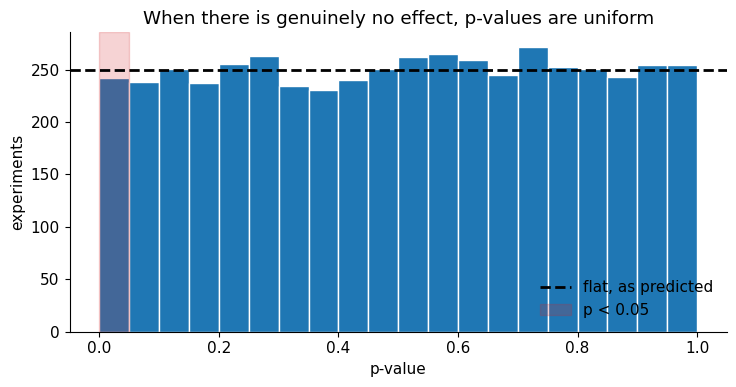

experiments with p < 0.05 : 0.048  (alpha was 0.05)
experiments with p < 0.01 : 0.009  (alpha was 0.01)


In [4]:
# --- p-values when the null is true: five thousand experiments with no effect
rng = np.random.default_rng(0)

n_per_group = 10
p_null = np.array([stats.ttest_ind(rng.normal(0, 1, n_per_group),
                                   rng.normal(0, 1, n_per_group)).pvalue
                   for _ in range(5000)])

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(p_null, bins=20, range=(0, 1), color="#1f77b4", edgecolor="white")
ax.axhline(len(p_null) / 20, color="black", lw=2, ls="--", label="flat, as predicted")
ax.axvspan(0, 0.05, color="#d62728", alpha=0.2, label="p < 0.05")
ax.set_xlabel("p-value"); ax.set_ylabel("experiments")
ax.set_title("When there is genuinely no effect, p-values are uniform")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"experiments with p < 0.05 : {(p_null < 0.05).mean():.3f}  (alpha was 0.05)")
print(f"experiments with p < 0.01 : {(p_null < 0.01).mean():.3f}  (alpha was 0.01)")

The histogram is flat. Under the null, every p-value is equally likely, and that is exactly what
makes alpha meaningful: choosing 0.05 guarantees a 5% false-positive rate, no more and no less.

It also shows the danger in one picture. There is nothing whatsoever to find in that simulation,
and yet 250 of the 5,000 experiments came out "significant". Run enough tests on nothing and you
will publish nothing, with a p-value attached.

<a id="section-1-3"></a>
## 1.3 Two ways to be wrong, and power

|  | H0 is true | H0 is false |
|---|---|---|
| **we reject H0** | Type I error (false positive), rate alpha | correct detection, rate = **power** |
| **we keep H0** | correct, rate 1 - alpha | Type II error (false negative), rate beta |

**Power** is the probability of detecting an effect that is really there, 1 - beta. It depends on
three things: how big the effect is, how variable the data are, and how many observations you
collect. The first two are the world's business; only the third is yours.

Now the same simulation, but with a real difference put in.

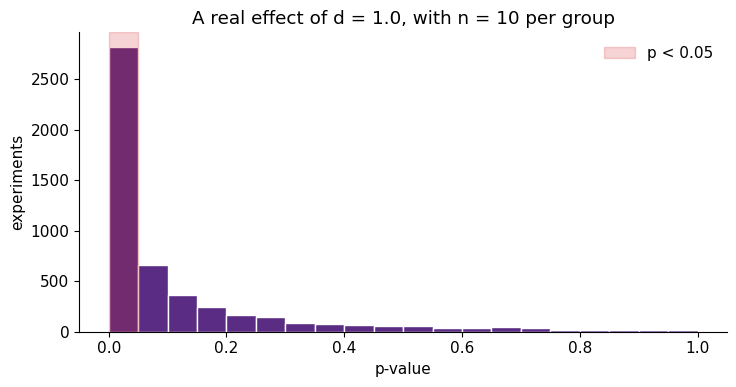

power at n = 10 per group, d = 1.0: 0.565
so 44% of these experiments MISS an effect that is really there


In [5]:
# --- p-values when the null is false: the same experiment with a real effect
rng = np.random.default_rng(1)
true_effect = 1.0        # in standard deviations: a large effect, Cohen's d = 1

p_effect = np.array([stats.ttest_ind(rng.normal(true_effect, 1, n_per_group),
                                     rng.normal(0, 1, n_per_group)).pvalue
                     for _ in range(5000)])

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(p_effect, bins=20, range=(0, 1), color="#5b2c83", edgecolor="white")
ax.axvspan(0, 0.05, color="#d62728", alpha=0.2, label="p < 0.05")
ax.set_xlabel("p-value"); ax.set_ylabel("experiments")
ax.set_title(f"A real effect of d = {true_effect}, with n = {n_per_group} per group")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

power = (p_effect < 0.05).mean()
print(f"power at n = {n_per_group} per group, d = {true_effect}: {power:.3f}")
print(f"so {100 * (1 - power):.0f}% of these experiments MISS an effect that is really there")

That last number deserves a moment. The effect is large by any standard, it is genuinely present
in every one of the five thousand simulated experiments, and with ten animals per group a
substantial fraction of them fail to detect it. A non-significant result is not evidence of
absence; quite often it is evidence of a small sample.

<a id="section-1-4"></a>
## 1.4 A first real test

Time to use the real data. Here is a question with an obvious null: **do trained mice use the
block prior at all?**

On zero-contrast trials the stimulus carries no information, but the rewarded side is still drawn
according to the block probability. A mouse that ignores the blocks should be correct on about
half of them. A mouse that follows the prior should do better than chance. So:

- H0: mean accuracy at zero contrast is 0.5
- H1: it is not 0.5 (two-sided, because we should be prepared to be surprised)

One number per mouse, thirty mice, and a **one-sample t-test** against 0.5.

n mice          : 30
mean accuracy   : 0.5898
t(29)          : 13.850
p-value         : 2.58e-14


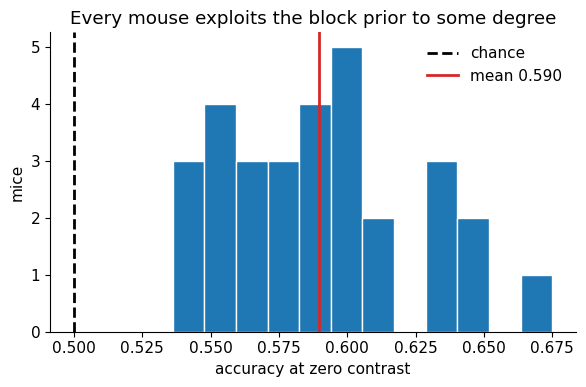

In [6]:
# --- Are trained mice above chance on zero-contrast trials?
zero_acc = zero.groupby("subject_id")["correct"].mean()

result = stats.ttest_1samp(zero_acc, popmean=0.5)
print(f"n mice          : {len(zero_acc)}")
print(f"mean accuracy   : {zero_acc.mean():.4f}")
print(f"t({len(zero_acc) - 1})          : {result.statistic:.3f}")
print(f"p-value         : {result.pvalue:.2e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(zero_acc, bins=12, color="#1f77b4", edgecolor="white")
ax.axvline(0.5, color="black", lw=2, ls="--", label="chance")
ax.axvline(zero_acc.mean(), color="#d62728", lw=2, label=f"mean {zero_acc.mean():.3f}")
ax.set_xlabel("accuracy at zero contrast"); ax.set_ylabel("mice")
ax.set_title("Every mouse exploits the block prior to some degree")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

> **▶ Task 1.1 ⭐ - Run a test and read the decision.**
> Using `zero_acc` from the cell above:
> 1. Re-run the one-sample test against a null of 0.55 instead of 0.5. Does the conclusion change?
> 2. Print the decision ("reject" or "do not reject") for alpha = 0.05 and for alpha = 0.001,
>    using an `if` statement.
> 3. In a comment: the p-value in the cell above is extremely small. Does that mean the effect is
>    large? Answer in one sentence.

In [7]:
# TODO 1.1 - your code here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
for null_value in [0.5, 0.55]:
    res = stats.ttest_1samp(zero_acc, popmean=null_value)
    print(f"H0: mean = {null_value}  ->  t = {res.statistic:6.3f}, p = {res.pvalue:.4g}")
    for alpha in [0.05, 0.001]:
        decision = "reject H0" if res.pvalue < alpha else "do not reject H0"
        print(f"    at alpha = {alpha:<6}: {decision}")

# No, a small p-value does not mean a large effect. It means the result would be very unlikely
# if the null were true, which depends just as much on the sample size and the variability as on
# the size of the effect itself. That is why we always report an effect size alongside it.
# --- END SOLUTION

H0: mean = 0.5  ->  t = 13.850, p = 2.582e-14
    at alpha = 0.05  : reject H0
    at alpha = 0.001 : reject H0
H0: mean = 0.55  ->  t =  6.141, p = 1.083e-06
    at alpha = 0.05  : reject H0
    at alpha = 0.001 : reject H0


> **▶ Task 1.2 ⭐ - One tail or two.**
> The test above was two-sided: it would have flagged mice performing *below* chance just as
> readily as above.
> 1. Re-run it as a one-sided test with `alternative="greater"`, and compare the two p-values.
> 2. Work out the exact relationship between them, and say in a comment why it holds.
> 3. In a comment: why would a one-sided test have been the wrong choice here, even though we
>    were confident about the direction beforehand?

In [8]:
# TODO 1.2 - your code here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
two_sided = stats.ttest_1samp(zero_acc, popmean=0.5)
one_sided = stats.ttest_1samp(zero_acc, popmean=0.5, alternative="greater")

print(f"two-sided p : {two_sided.pvalue:.4e}")
print(f"one-sided p : {one_sided.pvalue:.4e}")
print(f"ratio       : {two_sided.pvalue / one_sided.pvalue:.2f}")
# The one-sided p is exactly half the two-sided one whenever the effect points in the predicted
# direction, because the two-sided version counts the matching area in both tails.
# A one-sided test buys sensitivity by giving up the ability to detect the opposite result. Here
# a mouse performing reliably BELOW chance at zero contrast would be a fascinating finding, most
# likely a bug in the block logic or a mouse using an inverted rule, and a one-sided test would
# have reported it as a flat non-result.
# --- END SOLUTION

two-sided p : 2.5821e-14
one-sided p : 1.2910e-14
ratio       : 2.00


<a id="section-2"></a>
# Part 2. Building the t-test

<a id="section-2-1"></a>
## 2.1 The test statistic

A **test statistic** compresses the data into one number whose behaviour under the null we know.
For comparing two group means, the natural choice is the difference between them, divided by how
much that difference would wobble by chance:

$$t \;=\; \frac{\bar{x}_A - \bar{x}_B}{\text{SE of the difference}}$$

The numerator is the effect in the original units. The denominator is the standard error from
Notebook 3, now for a difference rather than a single mean. So t is the difference measured in
units of its own uncertainty, which is why "t = 2.3" means something without knowing whether we
measured seconds or spikes.

If we knew the population standard deviation we would compare t against a **Normal** distribution
and call it a z-test. We never know it, so we estimate it from the data, and that extra
uncertainty makes extreme values a little more likely than a Normal would suggest. The right
reference is **Student's t distribution**, which has heavier tails and one parameter, the
**degrees of freedom**, roughly the number of observations minus the number of quantities we had
to estimate. As n grows, t becomes indistinguishable from the Normal.

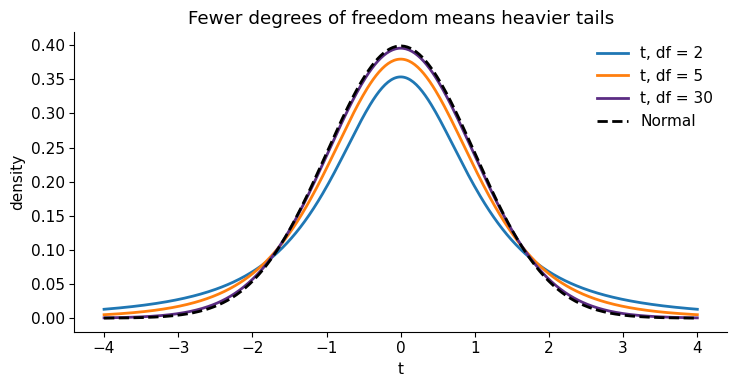

df =    2: 97.5th percentile = 4.303
df =    5: 97.5th percentile = 2.571
df =   30: 97.5th percentile = 2.042
df = 1000: 97.5th percentile = 1.962
   Normal: 97.5th percentile = 1.960


In [9]:
# --- Student's t against the Normal, for a few degrees of freedom
x = np.linspace(-4, 4, 400)

fig, ax = plt.subplots(figsize=(7.5, 4))
for df in [2, 5, 30]:
    ax.plot(x, stats.t.pdf(x, df), lw=2, label=f"t, df = {df}")
ax.plot(x, stats.norm.pdf(x), lw=2, color="black", ls="--", label="Normal")
ax.set_xlabel("t"); ax.set_ylabel("density")
ax.set_title("Fewer degrees of freedom means heavier tails")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

for df in [2, 5, 30, 1000]:
    print(f"df = {df:>4}: 97.5th percentile = {stats.t.ppf(0.975, df):.3f}")
print(f"{'Normal':>9}: 97.5th percentile = {stats.norm.ppf(0.975):.3f}")

Those critical values are the practical consequence. With 30 degrees of freedom you need t of
about 2.04 to reach p = 0.05; with only 2, you need 4.30. Small samples are punished, and
correctly so.

<a id="section-2-2"></a>
## 2.2 From scratch, against scipy

The formula for the two-sample (Student) t-test, assuming both groups share a variance:

$$s_p^2 = \frac{(n_A-1)s_A^2 + (n_B-1)s_B^2}{n_A + n_B - 2}, \qquad
t = \frac{\bar{x}_A - \bar{x}_B}{s_p\sqrt{\tfrac{1}{n_A} + \tfrac{1}{n_B}}}$$

with degrees of freedom $n_A + n_B - 2$. Implementing it once is the fastest way to stop thinking
of `ttest_ind` as a black box.

In [10]:
# --- The two-sample t-test, written out, then checked against scipy
def two_sample_t(a, b):
    """Student's two-sample t-test. Returns (t, degrees of freedom, two-sided p)."""
    n_a, n_b = len(a), len(b)
    var_a, var_b = np.var(a, ddof=1), np.var(b, ddof=1)

    pooled_var = ((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2)
    se_difference = np.sqrt(pooled_var * (1 / n_a + 1 / n_b))

    t = (np.mean(a) - np.mean(b)) / se_difference
    df = n_a + n_b - 2
    p = 2 * stats.t.sf(np.abs(t), df)        # sf is the upper tail; doubled for two sides
    return t, df, p

rng = np.random.default_rng(4)
a = rng.normal(0.5, 1.0, 12)
b = rng.normal(0.0, 1.0, 15)

mine = two_sample_t(a, b)
theirs = stats.ttest_ind(a, b, equal_var=True)

print(f"ours : t = {mine[0]:.6f}, df = {mine[1]}, p = {mine[2]:.6f}")
print(f"scipy: t = {theirs.statistic:.6f}, df = {theirs.df:.0f}, p = {theirs.pvalue:.6f}")
assert np.isclose(mine[0], theirs.statistic) and np.isclose(mine[2], theirs.pvalue)
print("\nthey agree")

ours : t = 1.393425, df = 25, p = 0.175757
scipy: t = 1.393425, df = 25, p = 0.175757

they agree


<a id="section-2-3"></a>
## 2.3 Assumptions: Student or Welch

The Student version above assumes the two groups have the **same variance**. When they do not,
it can be badly wrong, and the fix is **Welch's** t-test, which estimates the standard error
without pooling and adjusts the degrees of freedom downwards. `scipy` gives it with
`equal_var=False`, and it is the better default: when the variances really are equal it costs
almost nothing, and when they are not it saves you.

The other assumptions: observations should be **independent** (which is why we work with one
number per mouse and not one per trial), and the quantity being averaged should be roughly
**Normal**, or the sample large enough for the Central Limit Theorem to do the work.

Below, a case built to break the pooled version: same means, wildly different spreads and sizes.

In [11]:
# --- When the variances differ, the two tests disagree
rng = np.random.default_rng(7)
small_tight = rng.normal(0.0, 0.5, 8)
large_spread = rng.normal(0.6, 3.0, 40)

student = stats.ttest_ind(small_tight, large_spread, equal_var=True)
welch = stats.ttest_ind(small_tight, large_spread, equal_var=False)

print(f"group A: n = {len(small_tight):2d}, SD = {small_tight.std(ddof=1):.2f}")
print(f"group B: n = {len(large_spread):2d}, SD = {large_spread.std(ddof=1):.2f}\n")
print(f"Student: t = {student.statistic:6.3f}, df = {student.df:5.1f}, p = {student.pvalue:.4f}")
print(f"Welch  : t = {welch.statistic:6.3f}, df = {welch.df:5.1f}, p = {welch.pvalue:.4f}")

# Choosing between them with conditional logic: Levene's test asks whether the variances differ.
levene = stats.levene(small_tight, large_spread)
print(f"\nLevene test for equal variances: p = {levene.pvalue:.4f}")
if levene.pvalue < 0.05:
    print("-> variances look different, use Welch")
else:
    print("-> no evidence against equal variances, Student is fine (Welch still safe)")

group A: n =  8, SD = 0.37
group B: n = 40, SD = 2.60

Student: t =  0.510, df =  46.0, p = 0.6128
Welch  : t =  1.097, df =  44.7, p = 0.2785

Levene test for equal variances: p = 0.0030
-> variances look different, use Welch


<a id="section-2-4"></a>
## 2.4 Effect size and confidence interval

A p-value answers "could this be luck?". It does not answer "is this a lot?". For that we need
the **effect size**, and for two groups the standard one is **Cohen's d**, which is exactly the
standardised difference you built in Notebook 3:

$$d = \frac{\bar{x}_A - \bar{x}_B}{s_p}$$

Rules of thumb, to be used with suspicion: 0.2 small, 0.5 medium, 0.8 large. They are not laws,
and what counts as large depends entirely on the field.

The **confidence interval** puts the two together. A 95% CI for the difference is

$$(\bar{x}_A - \bar{x}_B) \;\pm\; t^*_{0.975,\,df}\times \text{SE of the difference}$$

and it is more informative than the p-value on its own, because it shows the size of the effect
*and* the uncertainty, in the units of the measurement. If the interval excludes zero, the test
is significant at that alpha, so the CI contains the p-value's answer and more.

In [12]:
# --- Cohen's d and a confidence interval for the difference
def cohens_d(a, b):
    """Standardised difference between two groups, using the pooled SD."""
    n_a, n_b = len(a), len(b)
    pooled_var = ((n_a - 1) * np.var(a, ddof=1) + (n_b - 1) * np.var(b, ddof=1)) / (n_a + n_b - 2)
    return (np.mean(a) - np.mean(b)) / np.sqrt(pooled_var)

def difference_ci(a, b, confidence=0.95):
    """Welch confidence interval for the difference between two group means.

    Welch rather than Student, so that this interval and the p-value from
    ttest_ind(..., equal_var=False) always tell the same story: the interval excludes
    zero exactly when the test is significant.
    """
    n_a, n_b = len(a), len(b)
    var_a, var_b = np.var(a, ddof=1), np.var(b, ddof=1)

    se = np.sqrt(var_a / n_a + var_b / n_b)
    # Welch-Satterthwaite: the effective degrees of freedom
    df = (var_a / n_a + var_b / n_b) ** 2 / (
        (var_a / n_a) ** 2 / (n_a - 1) + (var_b / n_b) ** 2 / (n_b - 1))

    margin = stats.t.ppf(0.5 + confidence / 2, df) * se
    difference = np.mean(a) - np.mean(b)
    return difference - margin, difference + margin

low, high = difference_ci(a, b)
print(f"difference : {np.mean(a) - np.mean(b):.3f}")
print(f"95% CI     : [{low:.3f}, {high:.3f}]")
print(f"Cohen's d  : {cohens_d(a, b):.3f}")
print(f"p-value    : {stats.ttest_ind(a, b).pvalue:.4f}")

difference : 0.608
95% CI     : [-0.278, 1.494]
Cohen's d  : 0.540
p-value    : 0.1758


> **▶ Task 2.1 ⭐⭐ - Complete the paired test from scratch.**
> The **paired** t-test applies when the same unit is measured twice: it works on the
> **differences** within each unit, and then it is just a one-sample test of those differences
> against zero. That removes all the between-unit variability, which is why pairing is so
> powerful.
>
> Complete the function below so that it returns `(t, df, p)`, and check it against
> `stats.ttest_rel` on the data provided.

In [13]:
# TODO 2.1 - your code here
def paired_t(before, after):
    """Paired t-test: a one-sample test on the within-unit differences."""
    differences = np.asarray(before) - np.asarray(after)
    # n = ...
    # mean_difference = ...
    # se = ...            (standard error of the mean difference)
    # t = ...
    # df = ...
    # p = ...             (two-sided)
    # return t, df, p

rng = np.random.default_rng(9)
before = rng.normal(10, 2, 15)
after = before + rng.normal(0.8, 1.0, 15)      # same units, measured twice

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
def paired_t(before, after):
    """Paired t-test: a one-sample test on the within-unit differences."""
    differences = np.asarray(before) - np.asarray(after)
    n = len(differences)
    mean_difference = np.mean(differences)
    se = np.std(differences, ddof=1) / np.sqrt(n)
    t = mean_difference / se
    df = n - 1
    p = 2 * stats.t.sf(np.abs(t), df)
    return t, df, p

mine = paired_t(before, after)
theirs = stats.ttest_rel(before, after)
print(f"ours : t = {mine[0]:.6f}, df = {mine[1]}, p = {mine[2]:.6f}")
print(f"scipy: t = {theirs.statistic:.6f}, df = {theirs.df:.0f}, p = {theirs.pvalue:.6f}")

unpaired = stats.ttest_ind(before, after)
print(f"\nfor comparison, the UNPAIRED test on the same data: "
      f"t = {unpaired.statistic:.3f}, p = {unpaired.pvalue:.4f}")
print("pairing removes the between-unit spread, so it finds the effect the unpaired test misses")
# --- END SOLUTION

ours : t = -3.259016, df = 14, p = 0.005709
scipy: t = -3.259016, df = 14, p = 0.005709

for comparison, the UNPAIRED test on the same data: t = -1.000, p = 0.3260
pairing removes the between-unit spread, so it finds the effect the unpaired test misses


> **▶ Task 2.2 ⭐⭐ - Let the data choose the test.**
> Write a function `compare_groups(a, b, alpha=0.05)` that:
> 1. runs Levene's test on the two groups;
> 2. picks Student's t-test if the variances look equal and Welch's if they do not;
> 3. returns a small dictionary with the test it used, t, p, Cohen's d and the 95% CI.
>
> Run it on the two artificial groups from section 2.3, and then on the genotype comparison you
> will build in Part 3. Does it choose the same test in both cases?

In [14]:
# TODO 2.2 - your code here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
def compare_groups(a, b, alpha=0.05):
    """Compare two groups, choosing Student or Welch according to Levene's test."""
    equal_variances = stats.levene(a, b).pvalue >= alpha
    result = stats.ttest_ind(a, b, equal_var=equal_variances)
    low, high = difference_ci(a, b)
    return {"test": "Student" if equal_variances else "Welch",
            "t": round(float(result.statistic), 3),
            "p": round(float(result.pvalue), 4),
            "cohens_d": round(float(cohens_d(a, b)), 3),
            "ci95": (round(float(low), 3), round(float(high), 3))}

print("artificial groups from 2.3:", compare_groups(small_tight, large_spread))
# --- END SOLUTION

artificial groups from 2.3: {'test': 'Welch', 't': 1.097, 'p': 0.2785, 'cohens_d': 0.197, 'ci95': (-0.396, 1.345)}


<a id="section-3"></a>
# Part 3. Inference on the real data

<a id="section-3-1"></a>
## 3.1 Three comparisons

Now the measurement from Notebook 3, tested three ways. The same number, the prior-updating
shift, split by three different groupings:

- **genotype**, wild-type against Cntnap2, both from the Angelaki lab, so the lab is held fixed;
- **lab**, the two wild-type cohorts against each other, same genotype, different institutions;
- **sex**, males against females, pooled across all thirty mice.

Only the first is a scientific hypothesis. The second is a **control**: if two groups of ordinary
wild-type mice differ as much as the genotypes do, that is a warning about how much of the first
result is really about genotype. The third is included because it is expected to show nothing,
and seeing a real null result is as instructive as seeing a significant one.

We report each one properly: t, degrees of freedom, p, Cohen's d, and a confidence interval.

In [15]:
# --- The three comparisons, reported in full
def report(name, a, b, label_a, label_b):
    """Run Welch's t-test and return a tidy row with everything worth reporting."""
    result = stats.ttest_ind(a, b, equal_var=False)
    low, high = difference_ci(a, b)
    return {"comparison": name,
            "groups": f"{label_a} vs {label_b}",
            "n": f"{len(a)} vs {len(b)}",
            "difference": np.mean(a) - np.mean(b),
            "95% CI": f"[{low:.3f}, {high:.3f}]",
            "t": result.statistic,
            "p": result.pvalue,
            "Cohen's d": cohens_d(a, b)}

by_cohort = {c: shift.loc[shift["cohort"] == c, "shift"].to_numpy() for c in COHORT_ORDER}
by_sex = {s: shift.loc[shift["sex"] == s, "shift"].to_numpy() for s in ["M", "F"]}

table = pd.DataFrame([
    report("genotype", by_cohort["NYU-WT"], by_cohort["CSP-ASD"], "NYU-WT", "CSP-ASD"),
    report("lab", by_cohort["CSHL-WT"], by_cohort["NYU-WT"], "CSHL-WT", "NYU-WT"),
    report("sex", by_sex["M"], by_sex["F"], "male", "female"),
])
print(table.round(4).to_string(index=False))

comparison            groups        n  difference          95% CI       t      p  Cohen's d
  genotype NYU-WT vs CSP-ASD 10 vs 10      0.0659  [0.004, 0.127]  2.2659 0.0375     1.0134
       lab CSHL-WT vs NYU-WT 10 vs 10      0.0978  [0.008, 0.188]  2.3118 0.0346     1.0339
       sex    male vs female 20 vs 10     -0.0439 [-0.135, 0.048] -1.0173 0.3245    -0.4172


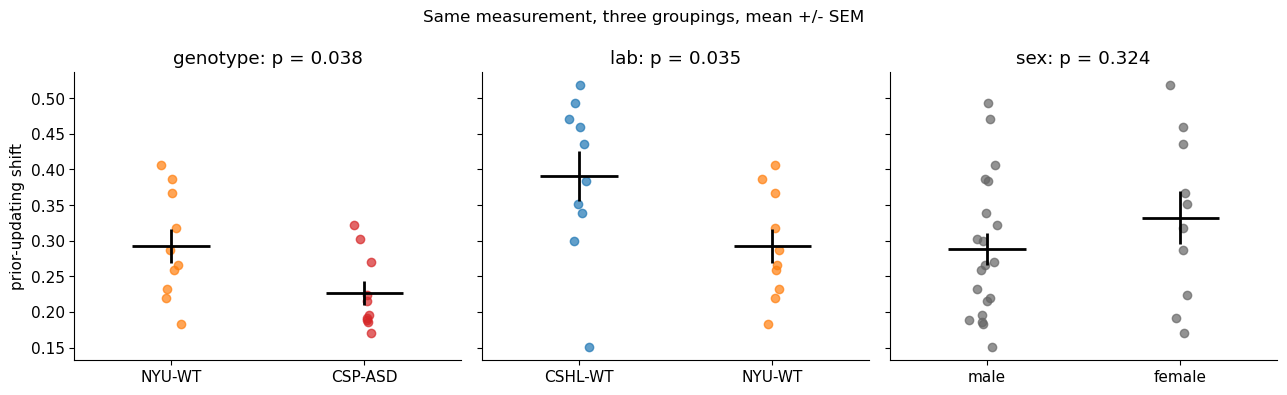

In [16]:
# --- The same three comparisons, drawn
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

panels = [("genotype", [("NYU-WT", by_cohort["NYU-WT"]), ("CSP-ASD", by_cohort["CSP-ASD"])]),
          ("lab", [("CSHL-WT", by_cohort["CSHL-WT"]), ("NYU-WT", by_cohort["NYU-WT"])]),
          ("sex", [("male", by_sex["M"]), ("female", by_sex["F"])])]

for ax, (title, groups) in zip(axes, panels):
    for i, (label, values) in enumerate(groups):
        jitter = np.random.default_rng(i).normal(0, 0.04, len(values))
        ax.plot(np.full(len(values), i) + jitter, values, "o", ms=6, alpha=0.7,
                color=COHORT_COLOR.get(label, "0.4"))
        ax.hlines(values.mean(), i - 0.2, i + 0.2, color="black", lw=2)
        sem = values.std(ddof=1) / np.sqrt(len(values))
        ax.vlines(i, values.mean() - sem, values.mean() + sem, color="black", lw=2)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([label for label, _ in groups])
    ax.set_xlim(-0.5, len(groups) - 0.5)
    p = table.loc[table["comparison"] == title, "p"].iloc[0]
    ax.set_title(f"{title}: p = {p:.3f}")

axes[0].set_ylabel("prior-updating shift")
fig.suptitle("Same measurement, three groupings, mean +/- SEM", fontsize=12)
fig.tight_layout()
plt.show()

Read that table carefully, because it contains the lesson of the week.

The **genotype** comparison is significant at 0.05, with a large Cohen's d. That is the result
the dataset was assembled to show, and it agrees with the published finding that Cntnap2 mice
rely less on prior expectations.

The **lab** comparison is also significant, with an effect size just as large. Two groups of
perfectly ordinary wild-type mice, differing only in which building they were trained in, differ
by about as much as the genotypes do. That does not invalidate the genotype result, which was
measured within a single lab precisely to avoid this. It does mean that anyone comparing the
Churchland wild-types against the Angelaki mutants would have found a "genotype effect" that was
partly a lab effect. Confounding is not a hypothetical.

The **sex** comparison shows nothing, with a p-value nowhere near significance and a small d. This
is a true negative, and the honest way to describe it is "we found no evidence of a difference",
not "we showed there is no difference". With ten or so mice per group, this test would miss a
moderate effect most of the time, as section 3.3 will show.

<a id="section-3-2"></a>
## 3.2 The paired version

There is a better way to ask whether mice use the prior at all. Each mouse gives us **two**
numbers, its choice rate in the 20% blocks and in the 80% blocks. Those are two measurements of
the same animal, so they are paired, and a paired test removes everything that makes one mouse
differ from another.

paired   : t(29) = 15.74, p = 9.565e-16
unpaired : t = 7.49, p = 4.441e-10

mean shift = 0.303, SD across mice = 0.105


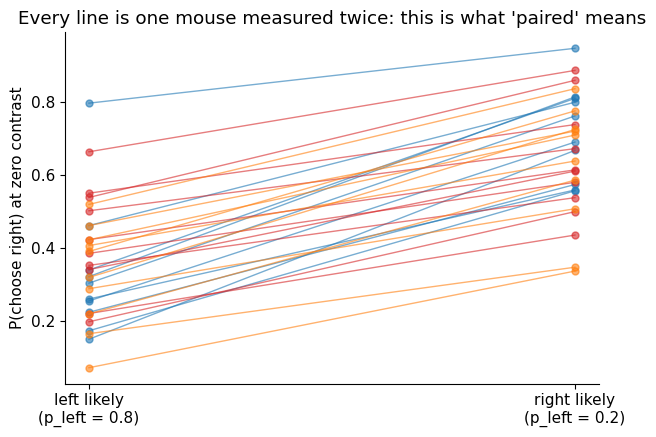

In [17]:
# --- Paired: each mouse measured in both block types
right_likely = shift["p_right_pleft_0.2"].to_numpy()
left_likely = shift["p_right_pleft_0.8"].to_numpy()

paired = stats.ttest_rel(right_likely, left_likely)
unpaired = stats.ttest_ind(right_likely, left_likely)

print(f"paired   : t({len(shift) - 1}) = {paired.statistic:.2f}, p = {paired.pvalue:.3e}")
print(f"unpaired : t = {unpaired.statistic:.2f}, p = {unpaired.pvalue:.3e}")
print(f"\nmean shift = {shift['shift'].mean():.3f}, "
      f"SD across mice = {shift['shift'].std(ddof=1):.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for _, row in shift.iterrows():
    ax.plot([0, 1], [row["p_right_pleft_0.8"], row["p_right_pleft_0.2"]],
            "-o", ms=5, lw=1, alpha=0.6, color=COHORT_COLOR[row["cohort"]])
ax.set_xticks([0, 1])
ax.set_xticklabels(["left likely\n(p_left = 0.8)", "right likely\n(p_left = 0.2)"])
ax.set_ylabel("P(choose right) at zero contrast")
ax.set_title("Every line is one mouse measured twice: this is what 'paired' means")
fig.tight_layout()
plt.show()

The paired test gives an enormous t. That is not because the effect got bigger, it is because the
noise got smaller: mice differ a lot from each other in how strongly they use the prior, and
pairing subtracts all of that away before asking the question. Whenever your design lets you
measure the same unit twice, use it.

<a id="section-3-3"></a>
## 3.3 Power, and why n = 10 is uncomfortable

The genotype comparison came out just under 0.05. That is a result worth having and also a
result worth being nervous about, because with ten mice per group the test is not very powerful.
Let us find out how powerful, by simulation: take the effect size we actually observed, generate
fake experiments of a given size, and count how often they reach significance.

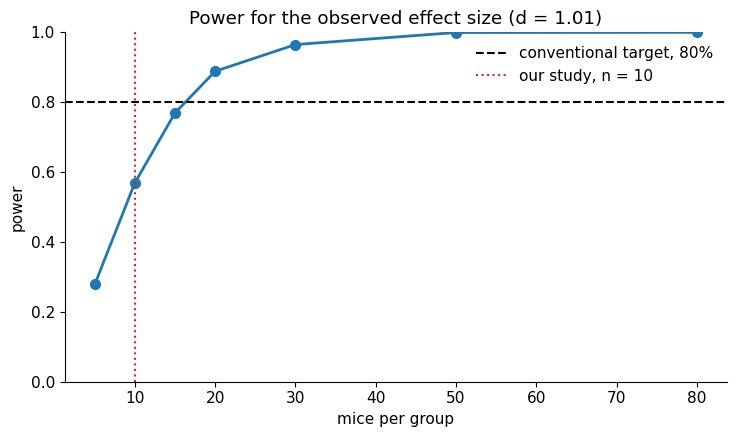

observed Cohen's d : 1.013
  n =   5 per group: power 0.28
  n =  10 per group: power 0.57
  n =  15 per group: power 0.77
  n =  20 per group: power 0.89
  n =  30 per group: power 0.96
  n =  50 per group: power 1.00
  n =  80 per group: power 1.00


In [18]:
# --- Power against sample size, at the effect size we observed
observed_d = cohens_d(by_cohort["NYU-WT"], by_cohort["CSP-ASD"])
rng = np.random.default_rng(12)

def simulate_power(effect_d, n_per_group, n_experiments=2000, alpha=0.05):
    """Fraction of simulated experiments that reach significance."""
    hits = 0
    for _ in range(n_experiments):
        a = rng.normal(effect_d, 1.0, n_per_group)
        b = rng.normal(0.0, 1.0, n_per_group)
        if stats.ttest_ind(a, b, equal_var=False).pvalue < alpha:
            hits += 1
    return hits / n_experiments

sizes = [5, 10, 15, 20, 30, 50, 80]
power_curve = [simulate_power(observed_d, n) for n in sizes]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sizes, power_curve, "o-", lw=2, ms=7)
ax.axhline(0.8, color="black", lw=1.5, ls="--", label="conventional target, 80%")
ax.axvline(10, color="#d62728", lw=1.5, ls=":", label="our study, n = 10")
ax.set_xlabel("mice per group"); ax.set_ylabel("power")
ax.set_ylim(0, 1)
ax.set_title(f"Power for the observed effect size (d = {observed_d:.2f})")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"observed Cohen's d : {observed_d:.3f}")
for n, p in zip(sizes, power_curve):
    print(f"  n = {n:>3} per group: power {p:.2f}")

Read the point at n = 10. Even taking the observed effect at face value, an experiment this size
detects it only about half the time. Flip that around: had the mice been slightly less
cooperative, the same real biological effect would have produced p = 0.12 and no result at all.

This is why a p-value just under 0.05 from a small sample should be reported as a promising
result rather than a settled one, and why the honest thing to publish alongside it is the effect
size and the confidence interval, both of which say plainly how much room for doubt is left.

> **▶ Task 3.1 ⭐⭐⭐ - Design the next experiment.**
> You are planning a replication and you want an 80% chance of detecting the effect.
> 1. Using `simulate_power`, find the smallest group size from the list `[10, 15, 20, 25, 30, 40, 60]`
>    that reaches 80% power at the observed effect size.
> 2. Repeat for an effect **half** as large, since observed effects from small significant studies
>    tend to be optimistic. How many mice now?
> 3. Plot both power curves on the same axes, with the 80% line marked.
> 4. In a comment: what does the comparison between the two curves say about planning experiments
>    from a previous study's effect size?

  observed d (d = 1.01): need 20 mice per group for 80% power


  half of it (d = 0.51): need more than 60 mice per group for 80% power


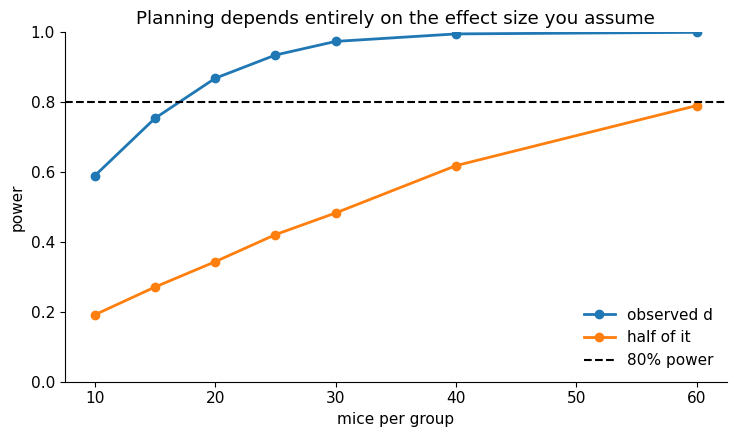

In [19]:
# TODO 3.1 - your code here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
sizes = [10, 15, 20, 25, 30, 40, 60]
curves = {}
for name, d in [("observed d", observed_d), ("half of it", observed_d / 2)]:
    curves[name] = [simulate_power(d, n) for n in sizes]
    enough = [n for n, p in zip(sizes, curves[name]) if p >= 0.8]
    answer = enough[0] if enough else "more than 60"
    print(f"{name:>12} (d = {d if isinstance(d, str) else round(d, 2)}): "
          f"need {answer} mice per group for 80% power")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name, curve in curves.items():
    ax.plot(sizes, curve, "o-", lw=2, ms=6, label=name)
ax.axhline(0.8, color="black", lw=1.5, ls="--", label="80% power")
ax.set_xlabel("mice per group"); ax.set_ylabel("power"); ax.set_ylim(0, 1)
ax.set_title("Planning depends entirely on the effect size you assume")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# Halving the assumed effect roughly quadruples the number of animals required, because power
# depends on d times sqrt(n). Since a small study only reaches significance when luck inflates
# its effect, planning the next experiment from its published d will systematically leave you
# underpowered. Plan for something smaller than what you saw.
# --- END SOLUTION

<a id="section-4"></a>
# 4. What comes next

You can now take a measurement, state a null, choose the right test, run it, and report it in a
way that lets a reader judge it: the statistic, the p-value, the effect size and the interval.
More importantly you have seen what the machinery does not do. It does not prove the null, it
does not measure importance, and it is quietly weak at the sample sizes most animal experiments
actually use.

Two threads continue directly:

- We tested three comparisons on one dataset today, and picked them in advance. Notebook 5 asks
  what happens when you test **many** things at once, which is where family-wise error, the false
  discovery rate and p-hacking come in, and it generalises the t-test to more than two groups
  with the **ANOVA**.
- Our tests assumed roughly Normal data and were run on thirty mice. Notebook 6 drops that
  assumption and gets its p-values by **resampling** instead, which works when the assumption
  does not.